<a href="https://www.kaggle.com/code/aamir28/llm-benchmark-tracker-2026?scriptVersionId=329372669" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/aamir28/global-llm-benchmark-tracker/llm_benchmark_tracker_2026.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (61, 32)
Columns: ['model_name', 'provider', 'release_date', 'model_family', 'parameter_size_b', 'context_window_k', 'is_open_weight', 'is_multimodal', 'is_reasoning_model', 'mmlu_score', 'humaneval_score', 'math_score', 'gpqa_score', 'gsm8k_score', 'hellaswag_score', 'arc_challenge_score', 'truthfulqa_score', 'mbpp_score', 'arena_elo', 'cost_input_per_1m_usd', 'cost_output_per_1m_usd', 'license_type', 'api_available', 'deployment_type', 'languages_supported', 'max_output_tokens', 'fine_tunable', 'tool_use', 'vision', 'audio', 'knowledge_cutoff', 'notes']


In [2]:
df.head(5)[['model_name','provider','mmlu_score','humaneval_score','math_score','arena_elo','is_open_weight']]

,model_name,provider,mmlu_score,humaneval_score,math_score,arena_elo,is_open_weight
0,GPT-4o,OpenAI,88.7,90.2,76.6,1287,False
1,GPT-4o-mini,OpenAI,82.0,87.2,70.2,1147,False
2,o3,OpenAI,96.7,97.9,97.3,1410,False
3,o4-mini,OpenAI,93.4,96.4,95.8,1360,False
4,GPT-4.5,OpenAI,89.1,91.0,78.2,1310,False


In [3]:
df.describe()[['mmlu_score','humaneval_score','math_score','arena_elo','cost_input_per_1m_usd']]

,mmlu_score,humaneval_score,math_score,arena_elo,cost_input_per_1m_usd
count,61.00000,61.000000,61.000000,61.000000,61.000000
mean,83.35082,82.544262,72.329508,1186.491803,2.322951
std,8.18009,11.628908,17.136747,130.734033,9.779427
min,64.10000,56.200000,35.200000,950.000000,0.000000
25%,77.30000,73.200000,58.800000,1073.000000,0.000000
50%,84.00000,84.100000,72.500000,1177.000000,0.000000
75%,89.50000,93.500000,85.700000,1298.000000,2.000000
max,96.70000,97.900000,97.800000,1410.000000,75.000000


<Axes: title={'center': 'Top Arena ELO by Provider (best model per lab)'}, ylabel='provider'>

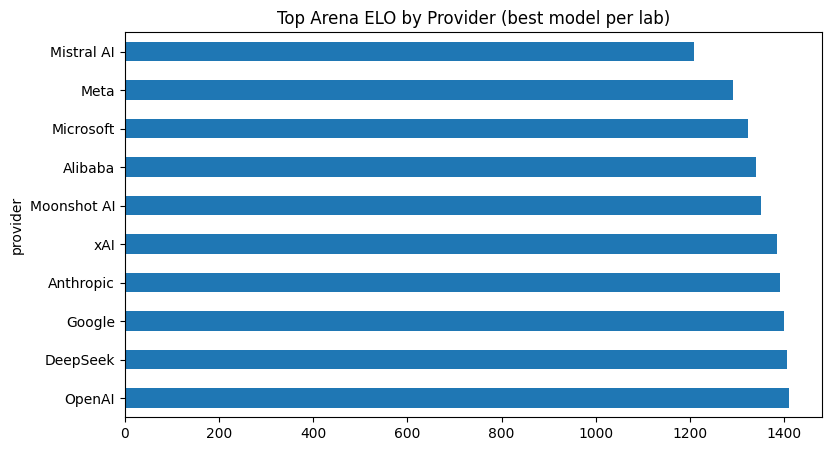

In [4]:
provider_top = df.groupby('provider')['arena_elo'].max().sort_values(ascending=False).head(10)
provider_top.plot(kind='barh', figsize=(9,5), title='Top Arena ELO by Provider (best model per lab)')

In [5]:

benchmarks = ['mmlu_score','humaneval_score','math_score','gpqa_score','arc_challenge_score']
reasoning = df[df['is_reasoning_model'] == True][benchmarks].mean()
standard  = df[df['is_reasoning_model'] == False][benchmarks].mean()
comparison = pd.DataFrame({'Reasoning': reasoning, 'Standard': standard})
print(comparison.round(1))

                     Reasoning  Standard
mmlu_score                92.8      80.8
humaneval_score           96.2      78.8
math_score                95.7      66.0
gpqa_score                74.0      40.8
arc_challenge_score       96.2      89.8


In [6]:
df['weight_type'] = df['is_open_weight'].map({True: 'Open-weight', False: 'Closed'})
df.groupby('weight_type')[['mmlu_score','humaneval_score','math_score','arena_elo']].mean().round(1)

,mmlu_score,humaneval_score,math_score,arena_elo
weight_type,,,,
Closed,87.2,87.2,78.6,1245.5
Open-weight,80.9,79.5,68.3,1148.2


Text(0, 0.5, 'Count')

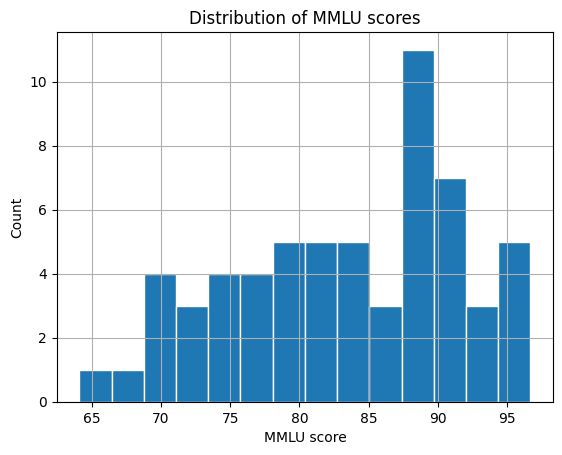

In [7]:
df['mmlu_score'].hist(bins=14, edgecolor='white')
plt.title('Distribution of MMLU scores')
plt.xlabel('MMLU score')
plt.ylabel('Count')

In [8]:
bench_cols = ['mmlu_score','humaneval_score','math_score','gpqa_score','arc_challenge_score']
df['composite_score'] = df[bench_cols].mean(axis=1).round(2)
top10 = df.nlargest(10, 'composite_score')[['model_name','provider','composite_score','arena_elo','is_open_weight']]
print(top10.to_string(index=False))

       model_name    provider  composite_score  arena_elo  is_open_weight
               o3      OpenAI            95.42       1410           False
   Gemini 2.5 Pro      Google            94.32       1399           False
      DeepSeek-R2    DeepSeek            94.26       1405            True
    Claude Opus 4   Anthropic            92.68       1390           False
           Grok-3         xAI            92.56       1385           False
          o4-mini      OpenAI            90.98       1360           False
      DeepSeek-R1    DeepSeek            90.18       1360            True
Claude 3.7 Sonnet   Anthropic            90.12       1360           False
        Kimi k1.5 Moonshot AI            90.12       1351           False
 Gemini 2.5 Flash      Google            88.76       1330           False


In [9]:
cost_models = df[df['cost_input_per_1m_usd'] > 0][['model_name','composite_score','cost_input_per_1m_usd','arena_elo']]
cost_models = cost_models.sort_values('cost_input_per_1m_usd')
print("Best performance-per-dollar models:")
cost_models['perf_per_dollar'] = (cost_models['composite_score'] / (cost_models['cost_input_per_1m_usd'] + 0.01)).round(1)
print(cost_models.nlargest(6,'perf_per_dollar')[['model_name','composite_score','cost_input_per_1m_usd','perf_per_dollar']])

Best performance-per-dollar models:
          model_name  composite_score  cost_input_per_1m_usd  perf_per_dollar
46         Nova Lite            63.90                   0.06            912.9
10  Gemini 2.0 Flash            81.92                   0.10            744.7
20       DeepSeek-V3            84.92                   0.14            566.1
12  Gemini 2.5 Flash            88.76                   0.15            554.8
48      Ministral 8B            58.18                   0.10            528.9
1        GPT-4o-mini            74.54                   0.15            465.9


In [10]:
caps = {'Vision': df['vision'].sum(), 'Audio': df['audio'].sum(),
        'Tool use': df['tool_use'].sum(), 'Fine-tunable': df['fine_tunable'].sum(),
        'Open weight': df['is_open_weight'].sum(), 'Reasoning': df['is_reasoning_model'].sum()}
pd.Series(caps).sort_values(ascending=False)

Tool use        54
Fine-tunable    37
Open weight     37
Vision          28
Reasoning       13
Audio            7
dtype: int64